In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
import torchvision.models as models

# ALIBI for explainability (install if necessary)
from alibi.explainers import AnchorImage, Counterfactual


In [6]:
import os
from torch.utils.data import Dataset

# Define the image transformations (resizing and normalization)
transform = transforms.Compose([
    transforms.Resize((224, 224)),   # Resize images to 224x224
    transforms.ToTensor(),           # Convert to tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalize with ImageNet mean and std
])

# Custom dataset class to load images and labels
class CustomImageDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        """
        Args:
            root_dir (string): Directory with all the images, organized in subfolders per class.
            transform (callable, optional): Optional transform to be applied on a sample.
        """
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []
        self.class_to_idx = {}

        # Collect image paths and labels
        for idx, class_name in enumerate(sorted(os.listdir(root_dir))):
            class_path = os.path.join(root_dir, class_name)
            if os.path.isdir(class_path):
                self.class_to_idx[class_name] = idx
                for img_name in os.listdir(class_path):
                    img_path = os.path.join(class_path, img_name)
                    if img_path.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')):
                        self.image_paths.append(img_path)
                        self.labels.append(idx)
        
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")  # Ensure RGB format
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)
        
        return image, label

# Example usage: replace 'root_dir' with the actual path to your dataset
root_dir = r"E:\1 Paper Work\Cutting Tool Paper\Dataset\cutting tool data\test_data_40_images"
dataset = CustomImageDataset(root_dir=root_dir, transform=transform)

# Check dataset details
print("Number of samples:", len(dataset))
print("Class to index mapping:", dataset.class_to_idx)


Number of samples: 280
Class to index mapping: {'BF': 0, 'BFI': 1, 'GF': 2, 'GFI': 3, 'N': 4, 'NI': 5, 'TF': 6}


In [7]:
from torch.utils.data import random_split, DataLoader

# Define split ratios
train_ratio = 0.8  # 80% for training
train_size = int(train_ratio * len(dataset))
val_size = len(dataset) - train_size

# Split the dataset
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# Create DataLoaders for training and validation
batch_size = 16  # You can adjust this based on your system's memory
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# Print dataset sizes
print("Training set size:", len(train_loader.dataset))
print("Validation set size:", len(val_loader.dataset))


Training set size: 224
Validation set size: 56


In [8]:

# Define a feature extractor model
class FeatureExtractor(nn.Module):
    def __init__(self):
        super(FeatureExtractor, self).__init__()
        self.backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)  # Pre-trained ResNet18
        self.backbone.fc = nn.Identity()  # Replace the final fully connected layer with an identity layer

    def forward(self, x):
        return self.backbone(x)

# Instantiate the feature extractor
feature_extractor = FeatureExtractor()

# Check feature embedding size
sample_input = torch.randn(1, 3, 224, 224)  # Dummy input for testing
sample_output = feature_extractor(sample_input)
print("Feature embedding size:", sample_output.shape)


Feature embedding size: torch.Size([1, 512])


In [9]:
# Define the fine-tuned model with a classification head
class FineTunedModel(nn.Module):
    def __init__(self, feature_extractor, n_classes):
        super(FineTunedModel, self).__init__()
        self.feature_extractor = feature_extractor
        self.fc = nn.Linear(512, n_classes)  # Fully connected layer for classification

    def forward(self, x):
        features = self.feature_extractor(x)
        return self.fc(features)

# Instantiate the model
n_classes = 7  # Number of classes: BF, BFI, GF, GFI, N, NI, TF
finetuned_model = FineTunedModel(feature_extractor, n_classes)

# Set up the optimizer and loss function
optimizer = optim.Adam(finetuned_model.parameters(), lr=1e-4)  # Learning rate can be adjusted
criterion = nn.CrossEntropyLoss()  # Suitable for multi-class classification


In [10]:
# Fine-tune the model
num_epochs = 10  # Adjust as needed
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    # Training Phase
    finetuned_model.train()
    running_train_loss = 0.0
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = finetuned_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation Phase
    finetuned_model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            outputs = finetuned_model(images)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item()

    avg_val_loss = running_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}] - Training Loss: {avg_train_loss:.4f}, Validation Loss: {avg_val_loss:.4f}")

print("Fine-tuning complete!")


Epoch [1/10] - Training Loss: 1.0272, Validation Loss: 1.5471
Epoch [2/10] - Training Loss: 0.2863, Validation Loss: 0.3774
Epoch [3/10] - Training Loss: 0.1077, Validation Loss: 0.0297
Epoch [4/10] - Training Loss: 0.0487, Validation Loss: 0.0892
Epoch [5/10] - Training Loss: 0.0338, Validation Loss: 0.0149
Epoch [6/10] - Training Loss: 0.0585, Validation Loss: 0.0041
Epoch [7/10] - Training Loss: 0.0252, Validation Loss: 0.0542
Epoch [8/10] - Training Loss: 0.0149, Validation Loss: 0.0026
Epoch [9/10] - Training Loss: 0.0070, Validation Loss: 0.0023
Epoch [10/10] - Training Loss: 0.0056, Validation Loss: 0.0020
Fine-tuning complete!


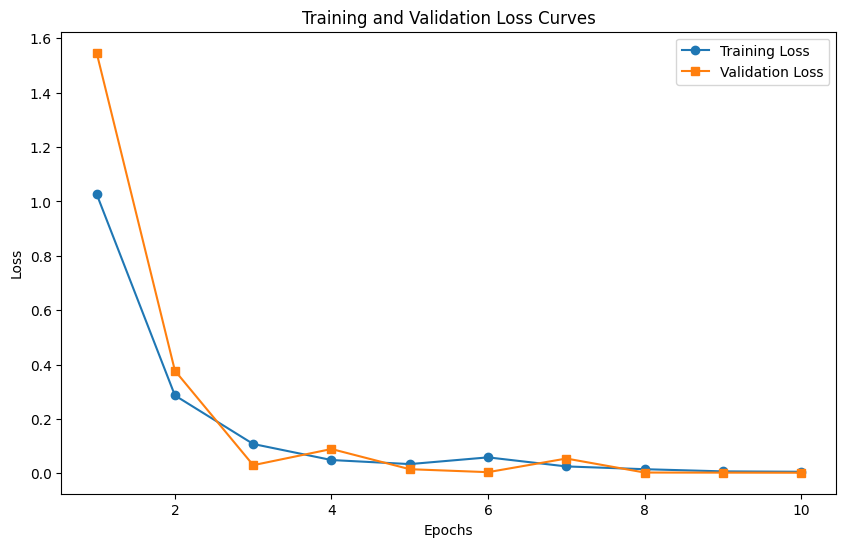

In [12]:
# Plotting the training and validation loss curves
plt.figure(figsize=(10, 6))
plt.plot(range(1, num_epochs + 1), train_losses, label='Training Loss', marker='o')
plt.plot(range(1, num_epochs + 1), val_losses, label='Validation Loss', marker='s')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Curves')
plt.legend()
#plt.grid(True)
plt.show()


In [16]:
from sklearn.manifold import TSNE

# Collect feature embeddings and labels from the validation set
val_features = []
val_labels = []

finetuned_model.eval()  # Set model to evaluation mode
with torch.no_grad():
    for images, labels in val_loader:
        features = finetuned_model.feature_extractor(images)  # Extract features
        val_features.append(features)
        val_labels.extend(labels.cpu().numpy())  # Store labels

# Convert lists to arrays for t-SNE
val_features = torch.cat(val_features).cpu().numpy()
val_labels = np.array(val_labels)

# Apply t-SNE to reduce feature dimensions to 2D
tsne = TSNE(n_components=2, random_state=42)
val_features_2d = tsne.fit_transform(val_features)



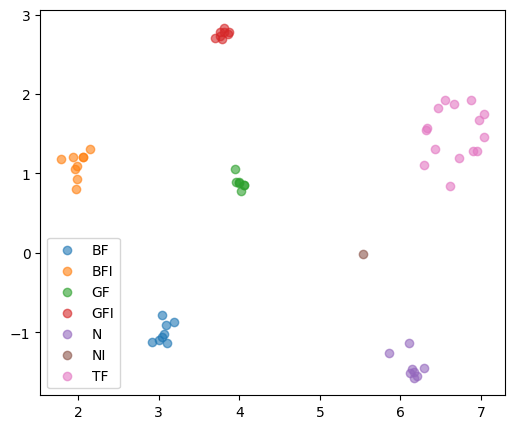

In [15]:
# Convert class_to_idx keys to a list for indexing
class_names = list(dataset.class_to_idx.keys())

# Plot t-SNE result
plt.figure(figsize=(6, 5))
for class_id in np.unique(val_labels):
    indices = val_labels == class_id
    plt.scatter(val_features_2d[indices, 0], val_features_2d[indices, 1], label=class_names[class_id], alpha=0.6)

plt.legend()
#plt.title('t-SNE Visualization of Validation Set Feature Embeddings')
#plt.xlabel("t-SNE Component 1")
#plt.ylabel("t-SNE Component 2")
plt.show()


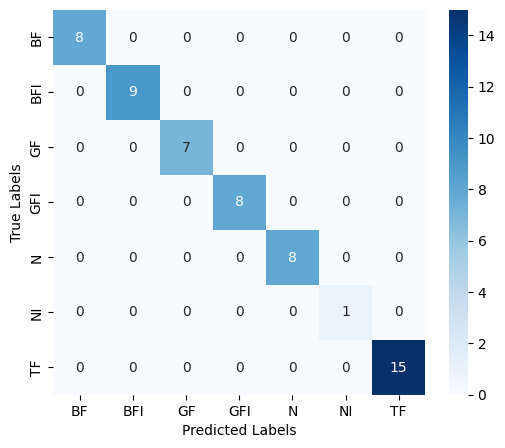

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Set model to evaluation mode
finetuned_model.eval()

# Collect true labels and predicted labels
true_labels = []
predicted_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        outputs = finetuned_model(images)
        _, preds = torch.max(outputs, 1)
        true_labels.extend(labels.cpu().numpy())
        predicted_labels.extend(preds.cpu().numpy())

# Generate confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Plot confusion matrix as a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
#plt.title("Confusion Matrix")
plt.show()


In [20]:
from sklearn.metrics import classification_report

# Generate the classification report
report = classification_report(true_labels, predicted_labels, target_names=class_names)
print(report)


              precision    recall  f1-score   support

          BF       1.00      1.00      1.00         8
         BFI       1.00      1.00      1.00         9
          GF       1.00      1.00      1.00         7
         GFI       1.00      1.00      1.00         8
           N       1.00      1.00      1.00         8
          NI       1.00      1.00      1.00         1
          TF       1.00      1.00      1.00        15

    accuracy                           1.00        56
   macro avg       1.00      1.00      1.00        56
weighted avg       1.00      1.00      1.00        56



Fuzzy Output: 0.5660628314973478


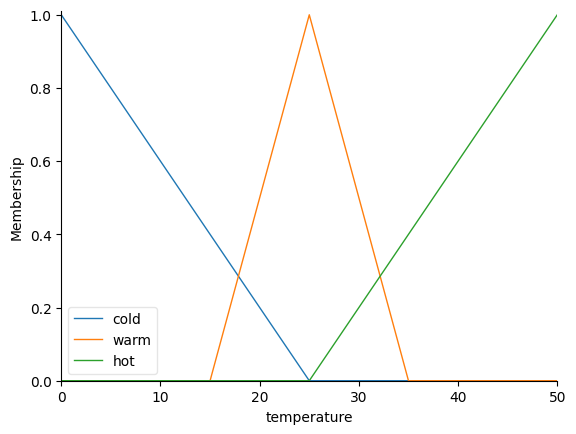

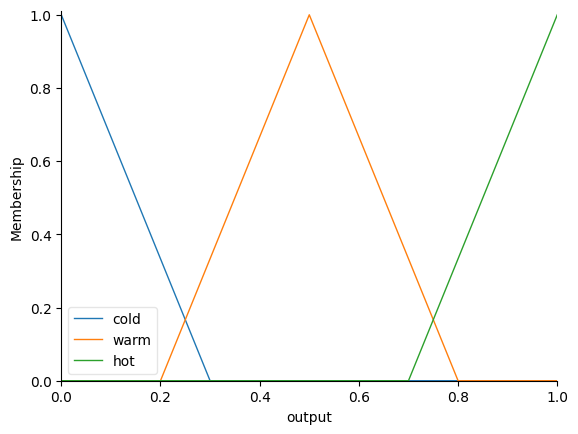

In [6]:
import numpy as np
import skfuzzy as fuzz
import skfuzzy.control as ctrl

# Define fuzzy variables
temperature = ctrl.Antecedent(np.arange(0, 51, 1), 'temperature')
output = ctrl.Consequent(np.arange(0, 1.1, 0.1), 'output')  # Output range 0 to 1

# Define fuzzy membership functions for TEMPERATURE (input)
temperature['cold'] = fuzz.trimf(temperature.universe, [0, 0, 25])
temperature['warm'] = fuzz.trimf(temperature.universe, [15, 25, 35])
temperature['hot'] = fuzz.trimf(temperature.universe, [25, 50, 50])

# ***DEFINE FUZZY MEMBERSHIP FUNCTIONS FOR OUTPUT***
# These define what "cold," "warm," and "hot" mean for the OUTPUT
output['cold'] = fuzz.trimf(output.universe, [0, 0, 0.3])    # Cold output (low value)
output['warm'] = fuzz.trimf(output.universe, [0.2, 0.5, 0.8])  # Warm output (medium value)
output['hot'] = fuzz.trimf(output.universe, [0.7, 1, 1])      # Hot output (high value)


# Define fuzzy rules
rule1 = ctrl.Rule(temperature['cold'], output['cold'])
rule2 = ctrl.Rule(temperature['warm'], output['warm'])
rule3 = ctrl.Rule(temperature['hot'], output['hot'])

# Control system
system = ctrl.ControlSystem([rule1, rule2, rule3])
sim = ctrl.ControlSystemSimulation(system)

# Test with a value
sim.input['temperature'] = 30  # Set temperature
sim.compute()

print("Fuzzy Output:", sim.output['output'])

# You can also visualize the membership functions (optional):
temperature.view()
output.view()

In [7]:
import numpy as np
import skfuzzy as fuzz
import skfuzzy.control as ctrl

# 1️⃣ Define Fuzzy Variables (Inputs & Outputs)
temperature = ctrl.Antecedent(np.arange(0, 51, 1), 'temperature')  # Input: Temperature (0°C to 50°C)
fan_speed = ctrl.Consequent(np.arange(0, 101, 1), 'fan_speed')  # Output: Fan Speed (0% to 100%)

# 2️⃣ Define Membership Functions
temperature['cold'] = fuzz.trimf(temperature.universe, [0, 0, 20])
temperature['warm'] = fuzz.trimf(temperature.universe, [10, 25, 40])
temperature['hot'] = fuzz.trimf(temperature.universe, [30, 50, 50])

fan_speed['low'] = fuzz.trimf(fan_speed.universe, [0, 0, 50])
fan_speed['medium'] = fuzz.trimf(fan_speed.universe, [25, 50, 75])
fan_speed['high'] = fuzz.trimf(fan_speed.universe, [50, 100, 100])

# 3️⃣ Define Fuzzy Rules
rule1 = ctrl.Rule(temperature['cold'], fan_speed['low'])
rule2 = ctrl.Rule(temperature['warm'], fan_speed['medium'])
rule3 = ctrl.Rule(temperature['hot'], fan_speed['high'])

# 4️⃣ Create and Simulate Fuzzy System
fan_control = ctrl.ControlSystem([rule1, rule2, rule3])
fan_sim = ctrl.ControlSystemSimulation(fan_control)

# 5️⃣ Give Input and Compute
fan_sim.input['temperature'] = 30  # Test with temperature = 30°C
fan_sim.compute()

print("Fan Speed Output:", fan_sim.output['fan_speed'])  # Show result



Fan Speed Output: 50.000000000000014
